# Kuramoto Model on Networks

### Simulate synchro dynamics for an ER and study how order parameter changes with coupling

In [13]:
library(igraph)
library(ggplot2)
library(RColorBrewer)
library(rgl)

In [ ]:
source("common.R")
set.seed(12)
N <- 200 # Set the number of nodes
M <- 1000 # Set the number of time steps
MC <- 1 # Set the number of Monte Carlo simulations

g <- erdos.renyi.game(N, p=2*log(N)/N, directed=FALSE)

$membership
  [1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [75] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[112] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[149] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[186] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

$csize
[1] 200

$no
[1] 1

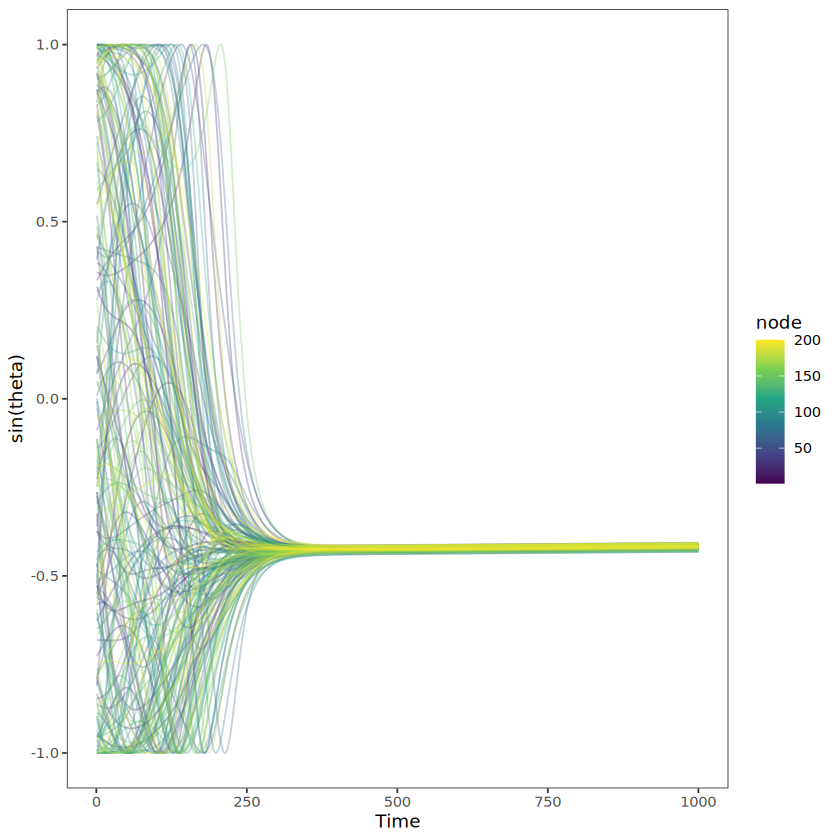

In [16]:
# Generate an ER 
g <- erdos.renyi.game(N, p=2*log(N)/N, directed=FALSE)
components(g)
E(g)$weight <- 1

MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=1)
plot.MultiTS(MultiTS)

In [17]:
res <- data.frame()
for(m in 1:10){
     cat(paste("MC #", m, "\n"))
     for(sigma in seq(0,0.3,0.005)){
          MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=sigma)

          x <- 0
          y <- 0
          for(i in 1:length(MultiTS)){
               x <- x + cos(MultiTS[[i]][M])
               y <- y + sin(MultiTS[[i]][M])
          }
          x <- x/N
          y <- y/N

          r <- sqrt(x^2 + y^2)

          res <- rbind(res, data.frame(mc=m, sigma=sigma, r=r))
     }
}

MC # 1 
MC # 2 
MC # 3 
MC # 4 
MC # 5 
MC # 6 
MC # 7 
MC # 8 
MC # 9 
MC # 10 


In [18]:
res

mc,sigma,r
<int>,<dbl>,<dbl>
1,0.000,0.02000547
1,0.005,0.12469719
1,0.010,0.02790318
1,0.015,0.07221710
1,0.020,0.13555615
1,0.025,0.13153390
1,0.030,0.15173760
1,0.035,0.14261283
1,0.040,0.19814989


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


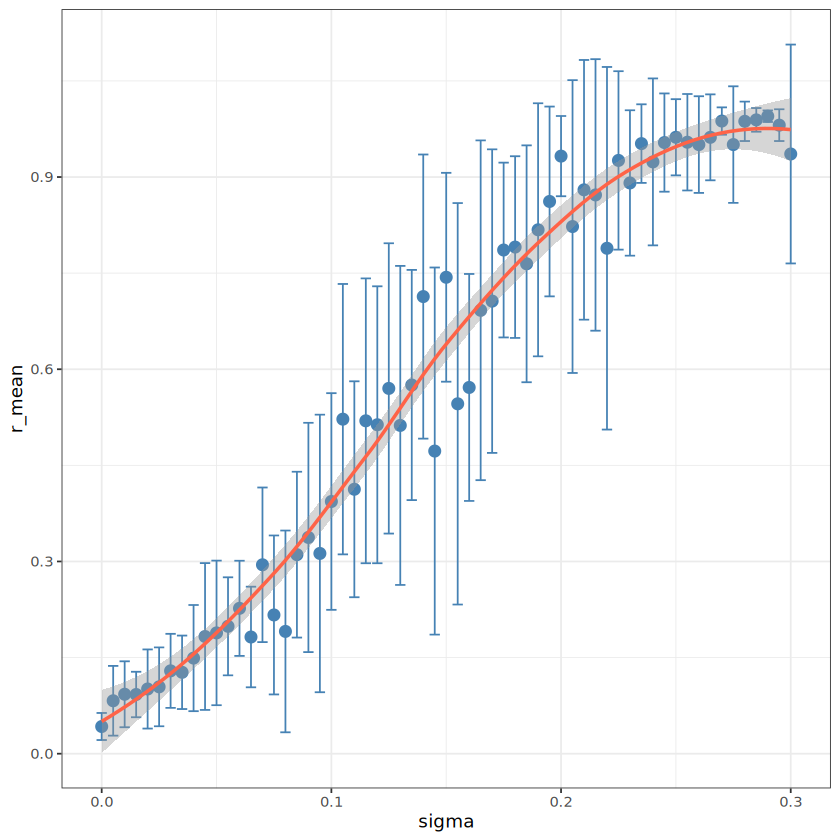

In [19]:
res_mean <- aggregate(r~sigma, res, mean)
res_sd <- aggregate(r~sigma, res, sd)
res_agg <- merge(res_mean, res_sd, by="sigma")
colnames(res_agg) <- c("sigma", "r_mean", "r_sd")
ggplot(res_agg, aes(sigma, r_mean)) + theme_bw() + geom_point(color="steelblue", size=3) + geom_errorbar(aes(ymin=r_mean-r_sd, ymax=r_mean+r_sd), color="steelblue") + geom_smooth(color="tomato")

### Change topology (WS, BA, SBM) and repeat

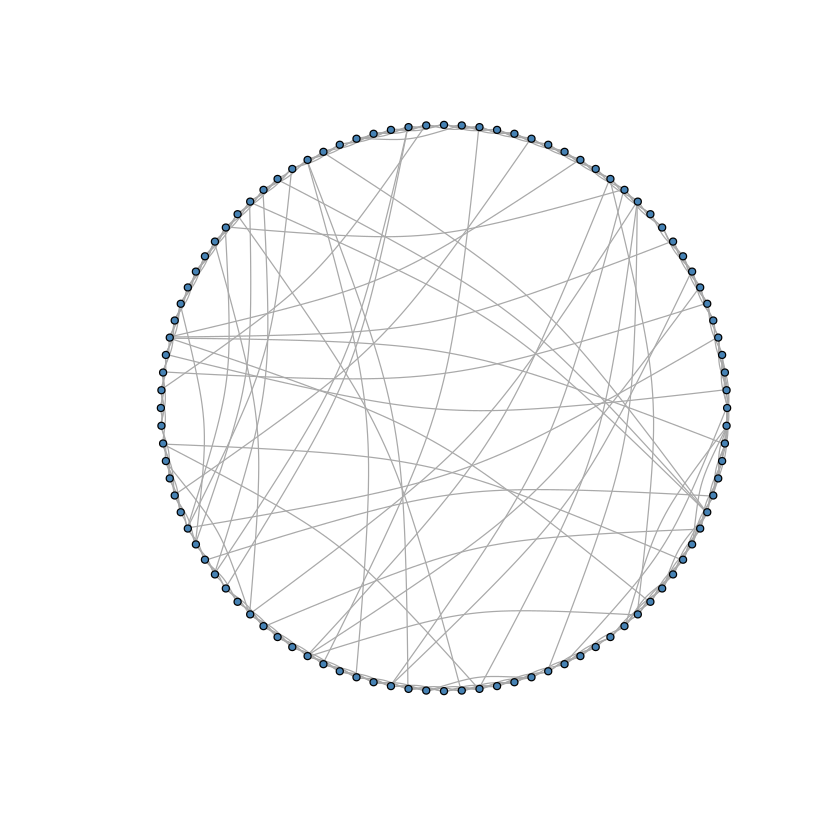

In [32]:
# Wattz - Strogatz
g <- sample_smallworld(dim=1, size=N, nei=3, p=0.1, loops = FALSE, multiple = FALSE)
E(g)$weight <- 1
lay <- layout_in_circle(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, vertex.size=2.5)

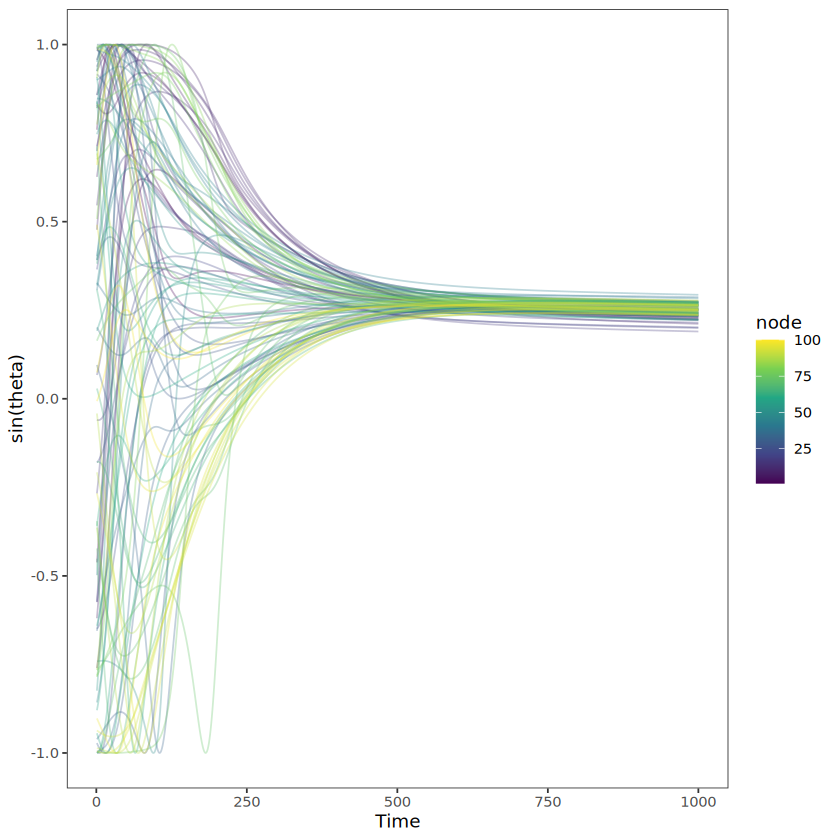

In [34]:
MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=1)
plot.MultiTS(MultiTS)

In [35]:
res <- data.frame()
for(m in 1:10){
     cat(paste("MC #", m, "\n"))
     for(sigma in seq(0,0.2,0.01)){
          MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=sigma)

          x <- 0
          y <- 0
          for(i in 1:length(MultiTS)){
               x <- x + cos(MultiTS[[i]][M])
               y <- y + sin(MultiTS[[i]][M])
          }
          x <- x/N
          y <- y/N

          r <- sqrt(x^2 + y^2)

          res <- rbind(res, data.frame(mc=m, sigma=sigma, r=r))
     }
}

MC # 1 
MC # 2 
MC # 3 
MC # 4 
MC # 5 
MC # 6 
MC # 7 
MC # 8 
MC # 9 
MC # 10 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


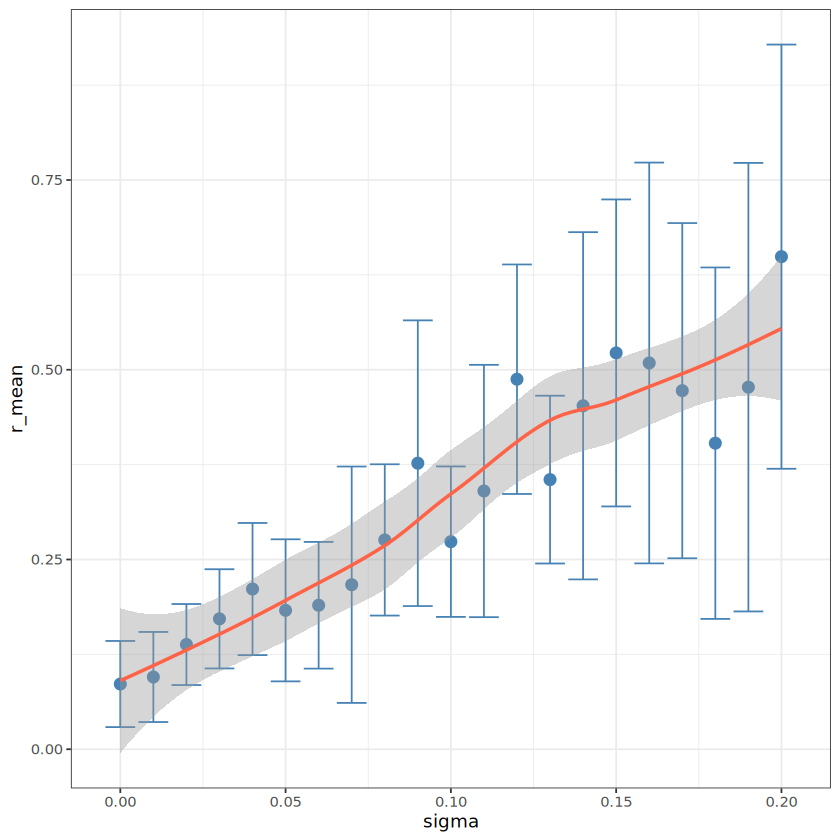

In [36]:
res_mean <- aggregate(r~sigma, res, mean)
res_sd <- aggregate(r~sigma, res, sd)
res_agg <- merge(res_mean, res_sd, by="sigma")
colnames(res_agg) <- c("sigma", "r_mean", "r_sd")
ggplot(res_agg, aes(sigma, r_mean)) + theme_bw() + geom_point(color="steelblue", size=3) + geom_errorbar(aes(ymin=r_mean-r_sd, ymax=r_mean+r_sd), color="steelblue") + geom_smooth(color="tomato")

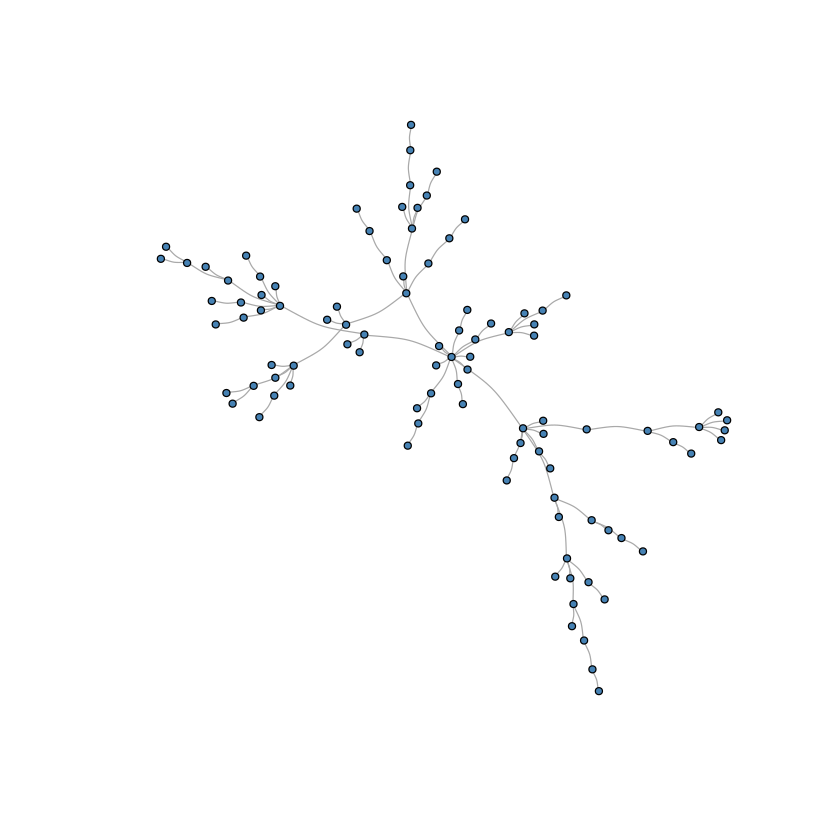

In [ ]:
# Barabasi - Albert
# if m=1, then the synchronization is very low
g <- sample_pa(n=N, m=1, directed=FALSE)
E(g)$weight <- 1
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, vertex.size=2.5)

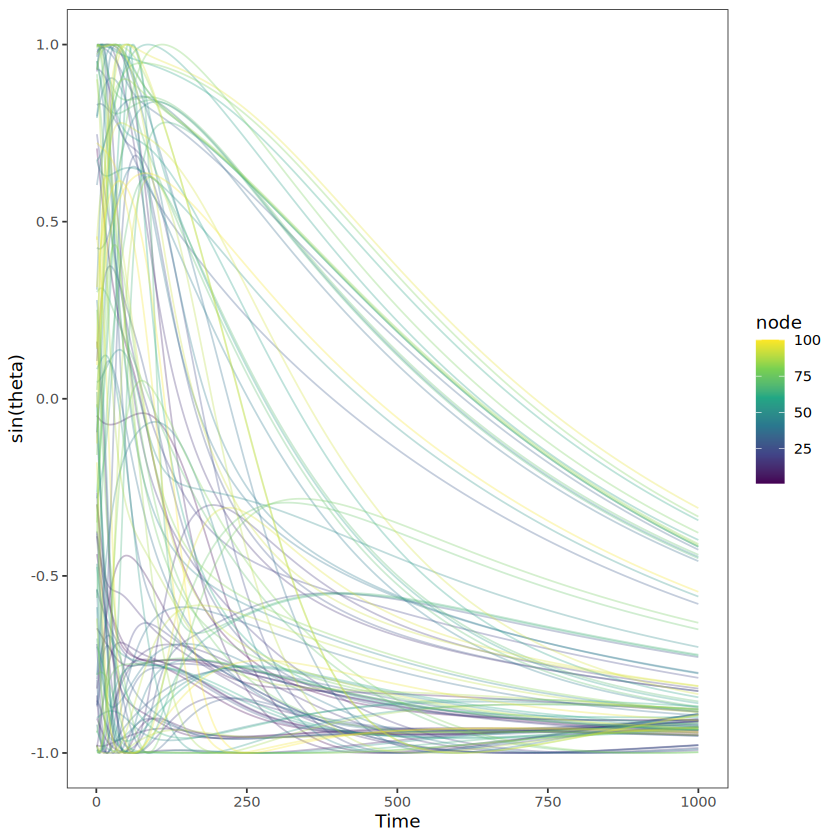

In [48]:
MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=1)
plot.MultiTS(MultiTS)

In [49]:
res <- data.frame()
for(m in 1:10){
     cat(paste("MC #", m, "\n"))
     for(sigma in seq(0,0.2,0.01)){
          MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=sigma)

          x <- 0
          y <- 0
          for(i in 1:length(MultiTS)){
               x <- x + cos(MultiTS[[i]][M])
               y <- y + sin(MultiTS[[i]][M])
          }
          x <- x/N
          y <- y/N

          r <- sqrt(x^2 + y^2)

          res <- rbind(res, data.frame(mc=m, sigma=sigma, r=r))
     }
}

MC # 1 
MC # 2 
MC # 3 
MC # 4 
MC # 5 
MC # 6 
MC # 7 
MC # 8 
MC # 9 
MC # 10 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


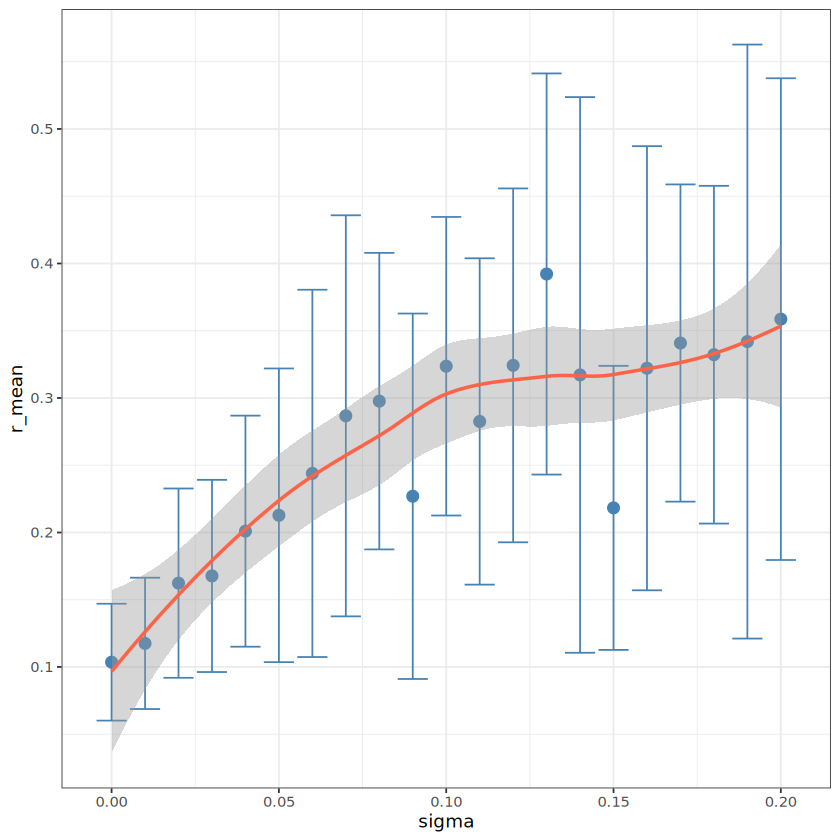

In [50]:
res_mean <- aggregate(r~sigma, res, mean)
res_sd <- aggregate(r~sigma, res, sd)
res_agg <- merge(res_mean, res_sd, by="sigma")
colnames(res_agg) <- c("sigma", "r_mean", "r_sd")
ggplot(res_agg, aes(sigma, r_mean)) + theme_bw() + geom_point(color="steelblue", size=3) + geom_errorbar(aes(ymin=r_mean-r_sd, ymax=r_mean+r_sd), color="steelblue") + geom_smooth(color="tomato")

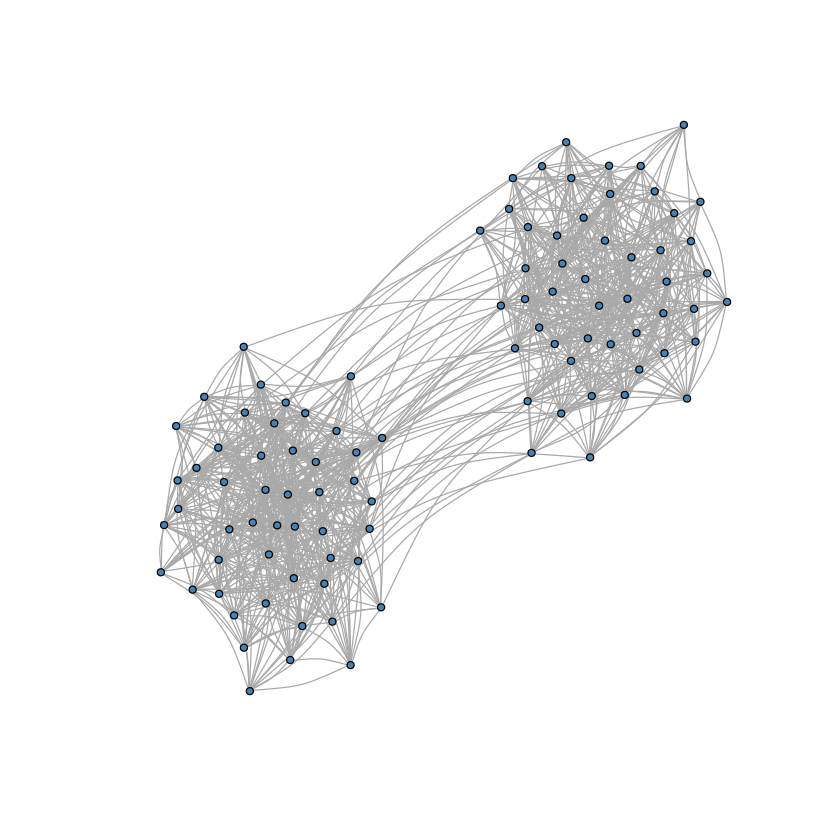

In [55]:
# Stochastic block model
OM <- matrix(0.02, ncol=2, nrow=2)
diag(OM) <- 0.4
g <- sample_sbm(n=N, pref.matrix=OM, block.sizes=c(N/2, N/2), directed=FALSE)
E(g)$weight <- 1
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, vertex.size=2.5)

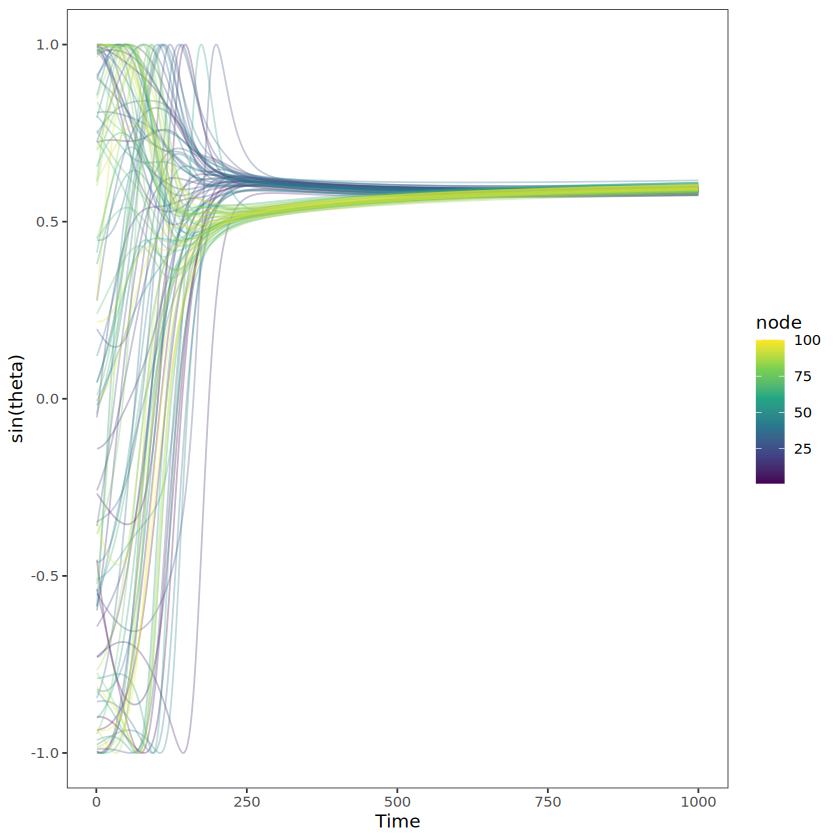

In [56]:
MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=1)
plot.MultiTS(MultiTS)

In [57]:
res <- data.frame()
for(m in 1:10){
     cat(paste("MC #", m, "\n"))
     for(sigma in seq(0,0.2,0.01)){
          MultiTS <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=sigma)

          x <- 0
          y <- 0
          for(i in 1:length(MultiTS)){
               x <- x + cos(MultiTS[[i]][M])
               y <- y + sin(MultiTS[[i]][M])
          }
          x <- x/N
          y <- y/N

          r <- sqrt(x^2 + y^2)

          res <- rbind(res, data.frame(mc=m, sigma=sigma, r=r))
     }
}

MC # 1 
MC # 2 
MC # 3 
MC # 4 
MC # 5 
MC # 6 
MC # 7 
MC # 8 
MC # 9 
MC # 10 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


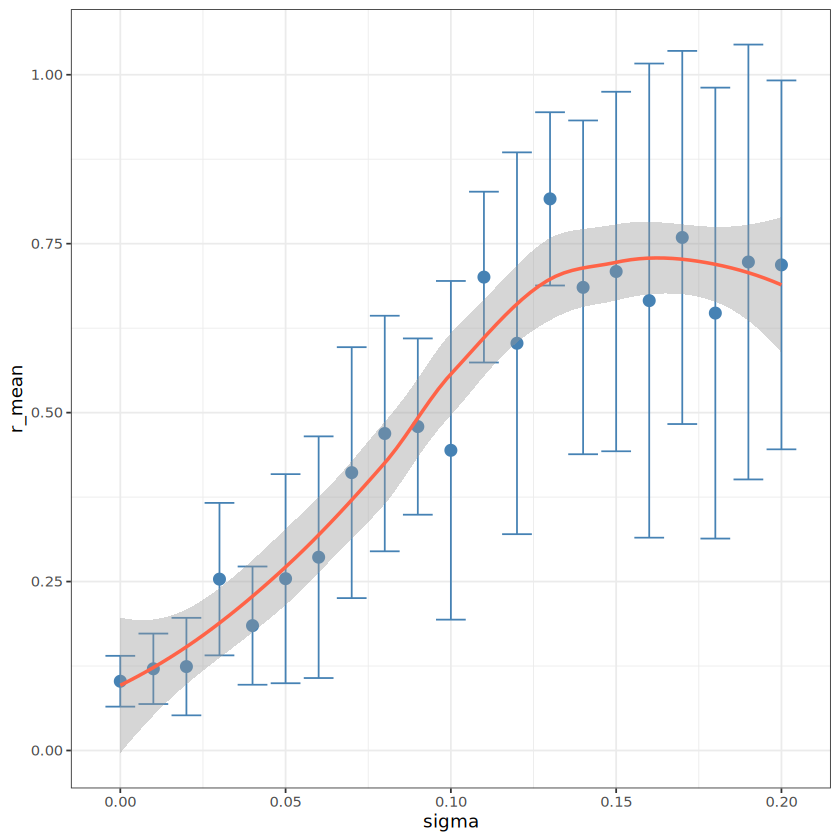

In [58]:
res_mean <- aggregate(r~sigma, res, mean)
res_sd <- aggregate(r~sigma, res, sd)
res_agg <- merge(res_mean, res_sd, by="sigma")
colnames(res_agg) <- c("sigma", "r_mean", "r_sd")
ggplot(res_agg, aes(sigma, r_mean)) + theme_bw() + geom_point(color="steelblue", size=3) + geom_errorbar(aes(ymin=r_mean-r_sd, ymax=r_mean+r_sd), color="steelblue") + geom_smooth(color="tomato")

### Compare: which network synch first? (Provided that other parameters are fairly equal)

The synch depends heavely on the network model, but also on the topology (so on the parameters) of the single ones. The network that synchs first is the Stochastic Block Model, as expected for its topology and high connectivity.

### Compare: Zachary network vs its configuration model (over a set of realizations)

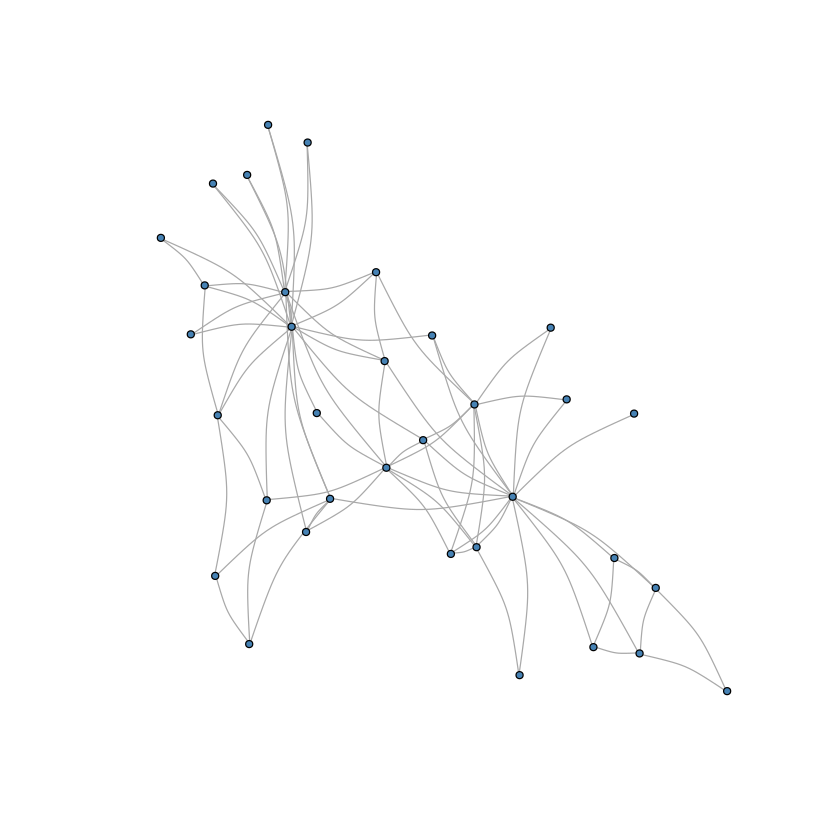

In [60]:
g <- make_graph('Zachary')
E(g)$weight <- 1
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, vertex.size=2.5)